# Time Series Anomaly Detection

## Loading data

In [1]:
# Connecting to kaggle
from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API configured successfully")

Saving kaggle.json to kaggle.json
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API configured successfully


!kaggle datasets download -d username/dataset-name

!unzip filename.zip -d destination_folder

In [2]:
# Loading Dataset
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
100% 40.4M/40.4M [00:00<00:00, 66.8MB/s]



In [3]:
# Unzipping
!unzip /content/cwru-bearing-datasets.zip -d /content/cwru-bearing
print("Dataset ready")

Archive:  /content/cwru-bearing-datasets.zip
  inflating: /content/cwru-bearing/CWRU_48k_load_1_CNN_data.npz  
  inflating: /content/cwru-bearing/feature_time_48k_2048_load_1.csv  
  inflating: /content/cwru-bearing/raw/B007_1_123.mat  
  inflating: /content/cwru-bearing/raw/B014_1_190.mat  
  inflating: /content/cwru-bearing/raw/B021_1_227.mat  
  inflating: /content/cwru-bearing/raw/IR007_1_110.mat  
  inflating: /content/cwru-bearing/raw/IR014_1_175.mat  
  inflating: /content/cwru-bearing/raw/IR021_1_214.mat  
  inflating: /content/cwru-bearing/raw/OR007_6_1_136.mat  
  inflating: /content/cwru-bearing/raw/OR014_6_1_202.mat  
  inflating: /content/cwru-bearing/raw/OR021_6_1_239.mat  
  inflating: /content/cwru-bearing/raw/Time_Normal_1_098.mat  
Dataset ready


## Exploring Data

In [4]:
os.listdir('/content/cwru-bearing')

['CWRU_48k_load_1_CNN_data.npz', 'raw', 'feature_time_48k_2048_load_1.csv']

- raw: likely a folder with raw vibration signal files. This is the most fundamental form of the data.
- CWRU_48k_load_1_CNN_data.npz: preprocessed data already formatted for CNN input. Someone has already done the feature extraction.
- feature_time_48k_2048_load_1.csv: time domain features already extracted into a

In [5]:
# Checking the raw file
os.listdir('/content/cwru-bearing/raw')

['OR014_6_1_202.mat',
 'B007_1_123.mat',
 'OR021_6_1_239.mat',
 'B021_1_227.mat',
 'IR014_1_175.mat',
 'Time_Normal_1_098.mat',
 'IR007_1_110.mat',
 'IR021_1_214.mat',
 'OR007_6_1_136.mat',
 'B014_1_190.mat']

The raw folder contains .mat files - MATLAB format.
- Time_Normal_1_098 - normal bearing data
- IR007, IR014, IR021 - Inner Race faults at different severities
- OR007, OR014, OR021 - Outer Race faults
- B007, B014, B021 - Ball faults

In [6]:
# Checking csv data file info
import pandas as pd
data = pd.read_csv('/content/cwru-bearing/feature_time_48k_2048_load_1.csv')

data

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1
...,...,...,...,...,...,...,...,...,...,...
2295,0.21425,-0.19839,0.010769,0.064100,0.064983,-0.212497,-0.119312,3.297037,6.034174,Normal_1
2296,0.21967,-0.20882,0.013136,0.068654,0.069883,-0.061308,-0.295122,3.143410,5.319958,Normal_1
2297,0.20799,-0.21613,0.012571,0.067128,0.068279,-0.154754,-0.071405,3.046161,5.431299,Normal_1
2298,0.21425,-0.22405,0.012608,0.066813,0.067977,-0.326966,0.023662,3.151821,5.391672,Normal_1


2,300 rows, 10 columns, 9 feature columns and 1 fault label column.

## Checking CSV data Feature
I decided to use the csv file as it is already prepared and my focus for this project is Anomaly detection and not signal processing.

In [7]:
data['fault'].unique()    #Checking unique fault column features

array(['Ball_007_1', 'Ball_014_1', 'Ball_021_1', 'IR_007_1', 'IR_014_1',
       'IR_021_1', 'OR_007_6_1', 'OR_014_6_1', 'OR_021_6_1', 'Normal_1'],
      dtype=object)

In [8]:
data['fault'].nunique()

10

In [9]:
data['fault'].value_counts()

,count
fault,
Ball_007_1,230
Ball_014_1,230
Ball_021_1,230
IR_007_1,230
IR_014_1,230
IR_021_1,230
OR_007_6_1,230
OR_014_6_1,230
OR_021_6_1,230


## Data preparation and cleaning

In [10]:
Normal = data[data['fault'] == 'Normal_1']
Faulty = data[data['fault'] != 'Normal_1']

print(Normal.shape)
print(Faulty.shape)

print(Normal)
print(Faulty)

(230, 10)
(2070, 10)
          max      min      mean        sd       rms  skewness  kurtosis  \
2070  0.20423 -0.19881  0.008002  0.066461  0.066925 -0.277750 -0.182979   
2071  0.20444 -0.19735  0.009596  0.063003  0.063714 -0.272165 -0.019003   
2072  0.21133 -0.18024  0.010816  0.063067  0.063973 -0.210367 -0.196338   
2073  0.20090 -0.19672  0.011418  0.064289  0.065280 -0.096509  0.103004   
2074  0.21154 -0.22781  0.012309  0.063622  0.064787 -0.225488 -0.034797   
...       ...      ...       ...       ...       ...       ...       ...   
2295  0.21425 -0.19839  0.010769  0.064100  0.064983 -0.212497 -0.119312   
2296  0.21967 -0.20882  0.013136  0.068654  0.069883 -0.061308 -0.295122   
2297  0.20799 -0.21613  0.012571  0.067128  0.068279 -0.154754 -0.071405   
2298  0.21425 -0.22405  0.012608  0.066813  0.067977 -0.326966  0.023662   
2299  0.19610 -0.24721  0.012209  0.063243  0.064396 -0.351762  0.226294   

         crest      form     fault  
2070  3.051634  8.363554  Nor

In [11]:
Normal2 = Normal.drop(columns=['fault'])
Faulty2 = Faulty.drop(columns=['fault'])

print(Normal2.shape)
print(Faulty2.shape)

print(Normal2)
print(Faulty2)

(230, 9)
(2070, 9)
          max      min      mean        sd       rms  skewness  kurtosis  \
2070  0.20423 -0.19881  0.008002  0.066461  0.066925 -0.277750 -0.182979   
2071  0.20444 -0.19735  0.009596  0.063003  0.063714 -0.272165 -0.019003   
2072  0.21133 -0.18024  0.010816  0.063067  0.063973 -0.210367 -0.196338   
2073  0.20090 -0.19672  0.011418  0.064289  0.065280 -0.096509  0.103004   
2074  0.21154 -0.22781  0.012309  0.063622  0.064787 -0.225488 -0.034797   
...       ...      ...       ...       ...       ...       ...       ...   
2295  0.21425 -0.19839  0.010769  0.064100  0.064983 -0.212497 -0.119312   
2296  0.21967 -0.20882  0.013136  0.068654  0.069883 -0.061308 -0.295122   
2297  0.20799 -0.21613  0.012571  0.067128  0.068279 -0.154754 -0.071405   
2298  0.21425 -0.22405  0.012608  0.066813  0.067977 -0.326966  0.023662   
2299  0.19610 -0.24721  0.012209  0.063243  0.064396 -0.351762  0.226294   

         crest      form  
2070  3.051634  8.363554  
2071  3.208700

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
scaled_normal = scaler.fit_transform(Normal2)
scaled_faulty = scaler.transform(Faulty2)

x_train, x_val = train_test_split(scaled_normal, test_size=0.2, random_state=42)

print(scaled_normal)
print(scaled_faulty)

[[-0.04550852  0.35002136 -1.77845302 ... -0.55378541 -0.16811885
   2.43245719]
 [-0.03443795  0.41653853 -1.14655182 ...  0.48577519  0.45521687
   0.95308642]
 [ 0.32878212  1.19606512 -0.66289888 ... -0.63847789  0.83124384
   0.33083891]
 ...
 [ 0.15270737 -0.43907276  0.03320539 ...  0.15356    -0.1898382
  -0.08410391]
 [ 0.48271573 -0.79990564  0.04757152 ...  0.75625989  0.22948424
  -0.11811348]
 [-0.47409765 -1.85506845 -0.11046589 ...  2.04088639 -0.19347906
  -0.21876684]]
[[ 8.15883677e+00 -9.67721450e+00  2.12218798e+00 ...  3.38590757e-01
  -7.62172613e-01  1.22003091e+00]
 [ 1.38448914e+01 -7.04431905e+00  3.87232650e+00 ...  8.92608869e-02
   1.54116232e+00  4.34186645e-01]
 [ 1.38886465e+01 -1.05515053e+01  3.16483013e+00 ... -1.13126692e+00
   3.50140169e-02  1.58569971e+00]
 ...
 [ 2.55261297e+02 -2.31493759e+02  2.88275667e-01 ...  1.49603696e+02
   1.85434569e+01  3.74599588e+01]
 [ 2.12054451e+02 -1.71373170e+02  3.58421453e-01 ...  6.94565112e+01
   1.43764686e

There is no y in an autoencoder.There is no y in an autoencoder.

In classification, y is the label, what the model is trying to predict.

In [13]:
print(x_train.shape)
print(x_val.shape)

(184, 9)
(46, 9)


## Training Model

In [14]:
# Importing Libaries
import torch.nn as nn

In [15]:
# Autoencoder Layer
import torch.nn as nn

class Autoencoder(nn.Module):
  def __init__(self):
    super(Autoencoder, self).__init__()

    # Encoder
    self.encoder = nn.Sequential(
        nn.Linear(9, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 4),
    )

    # Decoder
    self.decoder = nn.Sequential(
        nn.Linear(4, 8),
        nn.ReLU(),
        nn.Linear(8, 16),
        nn.ReLU(),
        nn.Linear(16, 9),
    )

  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)
    return x

In [16]:
model = Autoencoder()
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=9, bias=True)
  )
)


In [17]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [18]:
# Features
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [19]:
# Training
num_epochs = 100

x_train = torch.FloatTensor(x_train)
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for inputs in x_train:
    inputs = inputs.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, inputs)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  print(f'Epoch {epoch+1}, Loss: {running_loss/len(x_train):.4f}')

Epoch 1, Loss: 1.0320
Epoch 2, Loss: 1.0273
Epoch 3, Loss: 1.0232
Epoch 4, Loss: 1.0193
Epoch 5, Loss: 1.0153
Epoch 6, Loss: 1.0113
Epoch 7, Loss: 1.0071
Epoch 8, Loss: 1.0025
Epoch 9, Loss: 0.9976
Epoch 10, Loss: 0.9922
Epoch 11, Loss: 0.9861
Epoch 12, Loss: 0.9792
Epoch 13, Loss: 0.9714
Epoch 14, Loss: 0.9622
Epoch 15, Loss: 0.9515
Epoch 16, Loss: 0.9393
Epoch 17, Loss: 0.9254
Epoch 18, Loss: 0.9097
Epoch 19, Loss: 0.8926
Epoch 20, Loss: 0.8754
Epoch 21, Loss: 0.8586
Epoch 22, Loss: 0.8424
Epoch 23, Loss: 0.8273
Epoch 24, Loss: 0.8136
Epoch 25, Loss: 0.8012
Epoch 26, Loss: 0.7902
Epoch 27, Loss: 0.7798
Epoch 28, Loss: 0.7695
Epoch 29, Loss: 0.7592
Epoch 30, Loss: 0.7486
Epoch 31, Loss: 0.7373
Epoch 32, Loss: 0.7247
Epoch 33, Loss: 0.7108
Epoch 34, Loss: 0.6958
Epoch 35, Loss: 0.6792
Epoch 36, Loss: 0.6609
Epoch 37, Loss: 0.6411
Epoch 38, Loss: 0.6205
Epoch 39, Loss: 0.6007
Epoch 40, Loss: 0.5834
Epoch 41, Loss: 0.5692
Epoch 42, Loss: 0.5578
Epoch 43, Loss: 0.5490
Epoch 44, Loss: 0.54

## Model Evaluation

In [20]:
# Validation
model.eval()
with torch.no_grad():
    # Normal validation
    x_val_tensor = torch.FloatTensor(x_val).to(device)
    val_outputs = model(x_val_tensor)
    val_errors = torch.mean((x_val_tensor - val_outputs) ** 2, dim=1)

    # Fault data
    x_fault_tensor = torch.FloatTensor(scaled_faulty).to(device)
    fault_outputs = model(x_fault_tensor)
    fault_errors = torch.mean((x_fault_tensor - fault_outputs) ** 2, dim=1)

print(f"Mean reconstruction error - Normal: {val_errors.mean().item():.4f}")
print(f"Mean reconstruction error - Faulty: {fault_errors.mean().item():.4f}")

Mean reconstruction error - Normal: 0.2618
Mean reconstruction error - Faulty: 1709.8905


In [21]:
# Now let's set a threshold and measure actual detection performance
val_std = val_errors.std()
threshold = val_errors.mean() + 2 * val_errors.std()

fault_errors_np = fault_errors.cpu().numpy()
anomalies = fault_errors_np[fault_errors_np > threshold.item()]

print(f"Fault detection rate: {len(anomalies) / len(fault_errors_np) * 100:.2f}%")

Fault detection rate: 100.00%


## Plotting

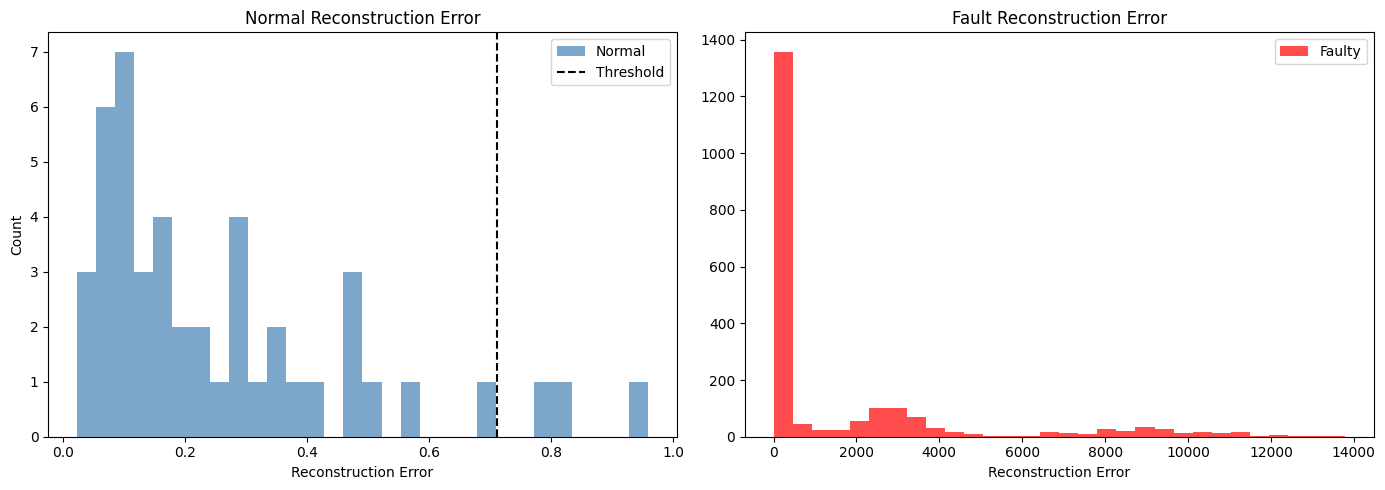

In [22]:
# Plotting Accuracies
import matplotlib.pyplot as plt

val_err = val_errors.cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(val_err, bins=30, alpha=0.7, color='steelblue', label='Normal')
ax1.axvline(x=threshold.item(), color='black', linestyle='--', label='Threshold')
ax1.set_title('Normal Reconstruction Error')
ax1.set_xlabel('Reconstruction Error')
ax1.set_ylabel('Count')
ax1.legend()

ax2.hist(fault_errors_np, bins=30, alpha=0.7, color='red', label='Faulty')
ax2.set_title('Fault Reconstruction Error')
ax2.set_xlabel('Reconstruction Error')
ax2.legend()

plt.tight_layout()
plt.savefig('reconstruction_error.png', dpi=150)
plt.show()

## Evaluation by fault type and severity

In [23]:
print(Faulty2.columns.tolist())

['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form']


In [24]:
print(Faulty['fault'].unique())

['Ball_007_1' 'Ball_014_1' 'Ball_021_1' 'IR_007_1' 'IR_014_1' 'IR_021_1'
 'OR_007_6_1' 'OR_014_6_1' 'OR_021_6_1']


In [25]:
import numpy as np

unique_faults = Faulty['fault'].unique()

print(f"Tracking detection rates for classes: {unique_faults}\n")
print(f"{'Fault Class':<20} | {'Total Samples':<15} | {'Detected':<10} | {'Detection Rate':<15}")
print("-" * 70)

for label in unique_faults:
    class_mask = (Faulty['fault'] == label).values
    subset_actual = scaled_faulty[class_mask]

    if len(subset_actual) == 0:
        continue
    with torch.no_grad():
        subset_tensor = torch.FloatTensor(subset_actual).to(device)
        subset_reconstructed = model(subset_tensor).cpu().numpy()

        reconstruction_error = np.mean(np.power(subset_actual - subset_reconstructed, 2), axis=1)

        detected_count = np.sum(reconstruction_error > threshold.item())
        detection_rate = (detected_count / len(subset_actual)) * 100

        print(f"{str(label):<20} | {len(subset_actual):<15} | {detected_count:<10} | {detection_rate:.2f}%")

Tracking detection rates for classes: ['Ball_007_1' 'Ball_014_1' 'Ball_021_1' 'IR_007_1' 'IR_014_1' 'IR_021_1'
 'OR_007_6_1' 'OR_014_6_1' 'OR_021_6_1']

Fault Class          | Total Samples   | Detected   | Detection Rate 
----------------------------------------------------------------------
Ball_007_1           | 230             | 230        | 100.00%
Ball_014_1           | 230             | 230        | 100.00%
Ball_021_1           | 230             | 230        | 100.00%
IR_007_1             | 230             | 230        | 100.00%
IR_014_1             | 230             | 230        | 100.00%
IR_021_1             | 230             | 230        | 100.00%
OR_007_6_1           | 230             | 230        | 100.00%
OR_014_6_1           | 230             | 230        | 100.00%
OR_021_6_1           | 230             | 230        | 100.00%


# Quantization and Edge Deployment of a ML Bearing Fault Detector

Quantization specifically reduces the precision of the numbers used to represent the model's weights. A standard PyTorch model stores weights as 32-bit floating point numbers (float32). Quantization converts them to 8-bit integers (int8) - reducing memory by 4x and speeding up inference because integer arithmetic is faster than floating point on most hardware.

The tradeoff is that you lose some precision - the weights are approximated rather than exact. The art is in measuring how much accuracy you lose versus how much size and speed you gain.

For edge devices like a Cortex-M4 microcontroller with 256KB of SRAM, a 6MB float32 model simply cannot fit. A quantized version at 1.5MB or less becomes deployable.

## Exporting the model to ONNX format

To export I need to provide a dummy input tensor that matches your model's expected input shape - 9 features

In [26]:
!pip install onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 12.3 MB/s eta 0:00:00


In [27]:
!pip install onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 90.6 MB/s eta 0:00:00


In [28]:
import torch
from onnxruntime.quantization.preprocess import quant_pre_process

dummy_input = torch.FloatTensor(1, 9).to(device)  # shape: 1 sample, 9 features. This is to show the ONNX what the input shape is

torch.onnx.export(
    model,
    dummy_input,
    "autoencoder.onnx",
    verbose=False,
    opset_version=17,
    input_names=["x"],
    output_names=["output"],
    dynamic_axes={"x": {0: "batch_size"}, "output": {0: "batch_size"}}
)

/tmp/ipykernel_22689/2962125705.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0519 23:56:22.208000 22689 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 17},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[batch_size,9]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,9]>
            ),
            initializers=(
                %"encoder.0.weight"<FLOAT,[16,9]>{TorchTensor(...)},
                %"encoder.0.bias"<FLOAT,[16]>{TorchTensor(...)},
                %"encoder.2.weight"<FLOAT,[8,16]>{TorchTensor(...)},
                %"encoder.2.bias"<FLOAT,[8]>{TorchTensor<FLOAT,[8]>(Parameter containing: tensor([ 0.1133,  0.1216,  0.1067,  0.3376,  0.3194, -0.0021,  0.2402,  0.2105], device='cuda:0', requires_grad=True), name='encoder.2.bias')},
                %"encoder.4.weight"<FLOAT,[4,8]>{TorchTensor(...)},
              

Now let check the file size of the exported model

In [29]:
size = os.path.getsize("autoencoder.onnx")
print(f"ONNX model size: {size / 1024:.2f} KB")

ONNX model size: 2.82 KB


## Measuring the baseline inference speed before quantization.

In [30]:
import onnxruntime as ort
import numpy as np
import time

# Loading the ONNX model
session = ort.InferenceSession("autoencoder.onnx")

# Preparing a sample input
sample = np.random.randn(1, 9).astype(np.float32)

# Warming up the process
for _ in range(10):
    session.run(None, {"x": sample})

# Measuring the latency
start = time.time()
for _ in range(1000):
    session.run(None, {"x": sample})
end = time.time()

print(f"Average inference latency: {(end - start) / 1000 * 1000:.4f} ms")

Average inference latency: 0.0386 ms


Now let's record the baseline detection performance before quantization so we can compare after.

In [31]:
# Baseline ONNX detection rate
normal_errors = []
for sample in x_val:
    input_data = sample.reshape(1, 9).astype(np.float32)
    output = session.run(None, {"x": input_data})[0]
    error = np.mean((input_data - output) ** 2)
    normal_errors.append(error)

normal_errors = np.array(normal_errors)
threshold_onnx = normal_errors.mean() + 2 * normal_errors.std()

fault_errors_onnx = []
for sample in scaled_faulty:
    input_data = sample.reshape(1, 9).astype(np.float32)
    output = session.run(None, {"x": input_data})[0]
    error = np.mean((input_data - output) ** 2)
    fault_errors_onnx.append(error)

fault_errors_onnx = np.array(fault_errors_onnx)
detected = np.sum(fault_errors_onnx > threshold_onnx)
print(f"ONNX Baseline - Normal error: {normal_errors.mean():.4f}")
print(f"ONNX Baseline - Fault error: {fault_errors_onnx.mean():.4f}")
print(f"ONNX Baseline - Detection rate: {detected/len(fault_errors_onnx)*100:.2f}%")

ONNX Baseline - Normal error: 0.2618
ONNX Baseline - Fault error: 1709.8906
ONNX Baseline - Detection rate: 100.00%


## Quantization

In [32]:
!pip install onnxruntime-tools -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.7/212.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.6 MB/s eta 0:00:00


In [33]:
# Pre-processing model before quantizating
quant_pre_process(
    input_model_path="autoencoder.onnx",
    output_model_path="autoencoder_preprocessed.onnx",
)

In [34]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="autoencoder_preprocessed.onnx",
    model_output="autoencoder_quantized.onnx",
    weight_type=QuantType.QInt8
)

size_quantized = os.path.getsize("autoencoder_quantized.onnx")
print(f"Quantized model size: {size_quantized / 1024:.2f} KB")

Quantized model size: 7.16 KB


## Comparison

In [35]:
# Size comparison
print(f"Original:   {os.path.getsize('autoencoder.onnx') / 1024:.2f} KB")
print(f"Quantized:  {os.path.getsize('autoencoder_quantized.onnx') / 1024:.2f} KB")

# Speed comparison on quantized model
session_q = ort.InferenceSession("autoencoder_quantized.onnx")
sample = np.random.randn(1, 9).astype(np.float32)
for _ in range(10):
    session_q.run(None, {"x": sample})
start = time.time()
for _ in range(1000):
    session_q.run(None, {"x": sample})
end = time.time()
print(f"Quantized inference latency: {(end - start) / 1000 * 1000:.4f} ms")

# Detection rate on quantized model
fault_errors_q = []
for s in scaled_faulty:
    input_data = s.reshape(1, 9).astype(np.float32)
    output = session_q.run(None, {"x": input_data})[0]
    fault_errors_q.append(np.mean((input_data - output) ** 2))

fault_errors_q = np.array(fault_errors_q)
detected_q = np.sum(fault_errors_q > threshold_onnx)
print(f"Quantized detection rate: {detected_q/len(fault_errors_q)*100:.2f}%")

Original:   2.82 KB
Quantized:  7.16 KB
Quantized inference latency: 0.0218 ms
Quantized detection rate: 100.00%


## Applying post-training quantization with TFLite